# ARTI 308 – Lab 5: Feature Engineering (Classification)
## Mobile Price Range Prediction using Hardware Specifications

### Lab focus
This dataset is already clean (no missing values, no duplicate rows, consistent data types).  
In this lab, we focus on **feature engineering** for a classification task, extracting new meaningful information from the existing hardware specifications.

### Objective
Build a baseline model to predict `price_range` (0, 1, 2, 3) and learn how feature engineering choices affect model performance and feature importance.

In this lab we will:
1) Load and inspect the dataset  
2) Define the target and select usable predictors (avoiding data leakage)  
3) Engineer new features (hardware-based and performance-based metrics like Screen Area)  
4) Discretize numerical features (binning)  
5) Train a baseline **Random Forest** classifier  
6) Interpret performance and feature importance

## 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load the dataset

In [2]:
DATA_PATH = "mobile_data.csv" 
df = pd.read_csv(DATA_PATH)

df.head(10)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1
5,1859,0,0.5,1,3,0,22,0.7,164,1,7,1004,1654,1067,17,1,10,1,0,0,1
6,1821,0,1.7,0,4,1,10,0.8,139,8,10,381,1018,3220,13,8,18,1,0,1,3
7,1954,0,0.5,1,0,0,24,0.8,187,4,0,512,1149,700,16,3,5,1,1,1,0
8,1445,1,0.5,0,0,0,53,0.7,174,7,14,386,836,1099,17,1,20,1,0,0,0
9,509,1,0.6,1,2,1,9,0.1,93,5,15,1137,1224,513,19,10,12,1,0,0,0


The first rows confirm that the dataset loaded correctly.  
Each row represents one mobile phone, including information about its hardware specifications (like RAM, battery power, screen size, and camera) and its target price category (`price_range`).

## 3. Quick dataset checks (cleanliness confirmation)

In [3]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (2000, 21)

Missing values per column:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


We confirm the dataset is clean: no missing values and no duplicated rows.  
Therefore, we will spend our effort on feature engineering rather than cleaning.

## 4. Target variable and class balance

In [4]:
target_col = "price_range"
df[target_col].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

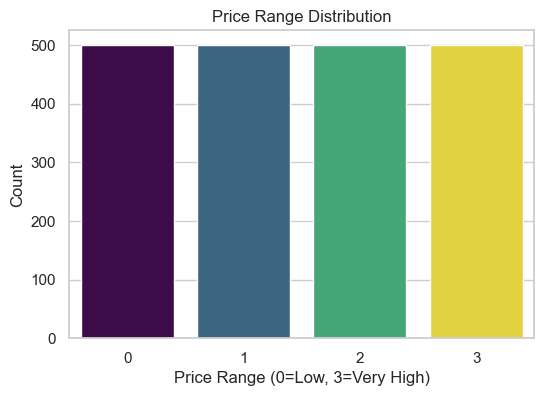

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x=target_col, data=df, hue=target_col, palette='viridis', legend=False)
plt.title("Price Range Distribution")
plt.xlabel("Price Range (0=Low, 3=Very High)")
plt.ylabel("Count")
plt.show()

This bar chart shows whether our target classes (`price_range`) are balanced. 

If one class heavily dominates, a machine learning model might become biased and learn to just guess that majority class all the time. Fortunately, looking at the chart above, we can see that our 4 price ranges (0, 1, 2, and 3) are perfectly balanced! 

Because the data is balanced, we can trust our basic Accuracy score, though we will still look at the classification report and confusion matrix to see exactly where the model makes mistakes.

## 5. Identify feature types

In [7]:
df.dtypes

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

Looking at the data types, we can see that our dataset consists entirely of numerical features (`int64` and `float64`), such as `battery_power`, `ram`, and `n_cores` (with some acting as binary categories like `blue` or `dual_sim`). 

Unlike many real-world datasets that have a messy mixture of text and numbers, this dataset is already numeric. However, feature engineering is still essential here so we can combine these raw specifications into more powerful, real-world metrics (like Screen Area or RAM per core) before modeling.

## 6. Leakage awareness (important)

When designing a prediction task, we must avoid using features that would not be available at prediction time.

For example, if we want to predict a mobile phone's `price_range` **before it is released to the market**, we should not use future metrics like:
- `total_sales_volume` (known only after months of selling)
- `average_customer_rating` (known only after people use it)

In this lab, our dataset consists entirely of physical hardware specifications (like RAM, battery, and camera). Since these are completely fixed and known at the time of manufacturing, we do not have any obvious "leakage" features to exclude from our model!

## 7. Feature engineering

### 7.1 Hardware-based features (Screen Area)
Since our dataset consists of physical specifications rather than timestamps, we will engineer new hardware metrics from the existing dimensions. 

For example, we can calculate the **Screen Area**:
- Multiply Screen Height (`sc_h`) by Screen Width (`sc_w`)
- This gives us a single, powerful metric representing the overall display size of the phone, which is highly relevant to a phone's price.

In [8]:
df_fe = df.copy()

# 1. Hardware-based feature: Screen Area
# We multiply screen height (sc_h) and width (sc_w) to get the total screen area.
df_fe["screen_area"] = df_fe["sc_h"] * df_fe["sc_w"]

df_fe[["sc_h", "sc_w", "screen_area"]].head(10)

,sc_h,sc_w,screen_area
0,9,7,63
1,17,3,51
2,11,2,22
3,16,8,128
4,8,2,16
5,17,1,17
6,13,8,104
7,16,3,48
8,17,1,17
9,19,10,190


We transformed the original timestamp into multiple meaningful features.  
Models often learn better from these engineered features than from raw timestamps.


### 7.2 Performance-based features
We create a new feature that captures the memory available per processor core:
`ram_per_core = ram / n_cores`

This can help the model differentiate between a phone that has high RAM but a weak processor, versus a well-balanced phone with both high memory and multiple processor cores. This balance is a very strong indicator of a phone's true performance and price category.

In [9]:
# 2. Performance-based feature: RAM per Core
# This gives us a metric of how much memory is available per processor core.
df_fe["ram_per_core"] = df_fe["ram"] / df_fe["n_cores"]

df_fe[["ram", "n_cores", "ram_per_core"]].head(10)

,ram,n_cores,ram_per_core
0,2549,2,1274.5
1,2631,3,877.0
2,2603,5,520.6
3,2769,6,461.5
4,1411,2,705.5
5,1067,1,1067.0
6,3220,8,402.5
7,700,4,175.0
8,1099,7,157.0
9,513,5,102.6


`ram_per_core` is a derived feature that may reflect the device tier, performance capability, or overall hardware balance.  
It is an example of domain-driven feature engineering.

### 7.3 Optional: Total Camera Megapixels
The dataset already includes separate features for the front camera (`fc`) and primary camera (`pc`).  
However, if both camera columns exist, we can compute an additional feature that combines them to represent the total photography capability of the phone.

This section is **optional** and will only run if the camera columns exist in the dataset.

In [10]:
# 3. Optional: Total Camera Megapixels
# Combining front (fc) and primary (pc) camera megapixels for a total photography score.
if {"fc", "pc"}.issubset(set(df_fe.columns)):
    df_fe["total_camera_mp"] = df_fe["fc"] + df_fe["pc"]
    display(df_fe[["fc", "pc", "total_camera_mp"]].head(10))
else:
    print("Camera columns not found. Skipping feature.")

,fc,pc,total_camera_mp
0,1,2,3
1,0,6,6
2,2,6,8
3,0,9,9
4,13,14,27
5,3,7,10
6,4,10,14
7,0,0,0
8,0,14,14
9,2,15,17


If computed, `total_camera_mp` is a hardware-based metric derived from the individual front and primary camera sensors.  
It can be used as an additional engineered feature to represent the overall photography capability of the device, providing a more holistic view than looking at either camera separately.

### 7.4 Reducing high-cardinality categories
In datasets with text categories (like restaurant names or item types), features can have hundreds of unique values. If we one-hot encode all of them, the dataset becomes incredibly huge and slows down the model. A common feature engineering approach is to keep the top most frequent categories and map the rest to `Other`.

However, in our **Mobile Phone dataset**, all features are already numerical or simple binary flags (like `blue` for Bluetooth or `dual_sim`). We do not have any high-cardinality text columns, so we do not need to perform this reduction step here!

In [13]:
# 4. Reducing high-cardinality categories
print("Our mobile dataset only contains numeric or binary (0/1) features. There are no high-cardinality text categories (like restaurant names) that need to be reduced in this specific dataset!")

Our mobile dataset only contains numeric or binary (0/1) features. There are no high-cardinality text categories (like restaurant names) that need to be reduced in this specific dataset!


Because our dataset does not contain any high-cardinality text features, our feature space naturally remains compact. 
This inherent simplicity in the data helps improve model stability and reduces the risk of overfitting right from the start, especially for our baseline models.

## 8. Discretization (binning)

Discretization converts a continuous numerical feature into categories (bins). 
This can help some models capture non-linear relationships, and it also improves interpretability.

Here we discretize `battery_power` into simple tiers (Low, Medium, High, and Very High).

In [14]:
# Discretization: Binning battery power into understandable tiers
df_fe["battery_tier"] = pd.cut(
    df_fe["battery_power"],
    bins=[0, 1000, 1500, 2000, np.inf],
    labels=["low", "medium", "high", "very_high"]
)

df_fe[["battery_power", "battery_tier"]].head(10)

,battery_power,battery_tier
0,842,low
1,1021,medium
2,563,low
3,615,low
4,1821,high
5,1859,high
6,1821,high
7,1954,high
8,1445,medium
9,509,low


`battery_tier` groups continuous numeric values into understandable categories.  
This may help the model capture patterns, such as higher price classifications for phones with very large batteries, if such a trend exists.

## 9. Prepare features for modeling


We now select our predictors.

We will drop:
- The target variable (`price_range`) to separate it from our feature matrix.
- (Note: Unlike other datasets, we do not have meaningless IDs or future leakage features to drop here!)

We will keep:
- All original hardware specifications (numeric and binary variables).
- Our newly engineered features (`screen_area`, `ram_per_core`, `battery_tier`).

In [15]:
# We drop the target column to create our feature matrix (X)
drop_cols = []

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (2000, 24)
y shape: (2000,)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,screen_area,ram_per_core,total_camera_mp,battery_tier
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,63,1274.5,3,low
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,51,877.0,6,medium
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,22,520.6,8,low
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,128,461.5,9,low
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,16,705.5,27,high


We prepared a feature matrix `X` and a target vector `y`.  
The feature matrix includes our newly engineered features such as hardware-based metrics (screen area), performance-based metrics (RAM per core), and discretized categories (battery tiers).

## 10. Split into train and test sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1600, 24)
Test size: (400, 24)


We use stratified splitting (`stratify=y`) to keep the class proportions exactly the same in both our training and testing sets.  

Although our `price_range` classes are already perfectly balanced, using stratified splitting guarantees that this perfect even split is strictly maintained across both sets. This ensures our model trains and is evaluated completely fairly across all mobile phone price tiers.

## 11. Encoding and baseline model (Random Forest)

### Why encoding?
Machine learning models require numerical input.  
Categorical variables (such as the `battery_tier` we just engineered) must be converted into numbers. Here we use **One-Hot Encoding** to transform these categories into a format our model can process.

### Why Random Forest for this lab?
We use Random Forest as a baseline because:
- it handles mixed features well (combining our continuous hardware numbers with our engineered categorical tiers)
- it is robust and fast to set up for baseline testing
- it provides feature importance to help us interpret which hardware specifications (like RAM or battery) actually drive up the phone's price

In [17]:
# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model

Categorical columns: ['battery_tier']
Numeric columns: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'screen_area', 'ram_per_core', 'total_camera_mp']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

## 12. Train the model and evaluate

In [21]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       100
           1       0.84      0.83      0.83       100
           2       0.83      0.83      0.83       100
           3       0.95      0.94      0.94       100

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



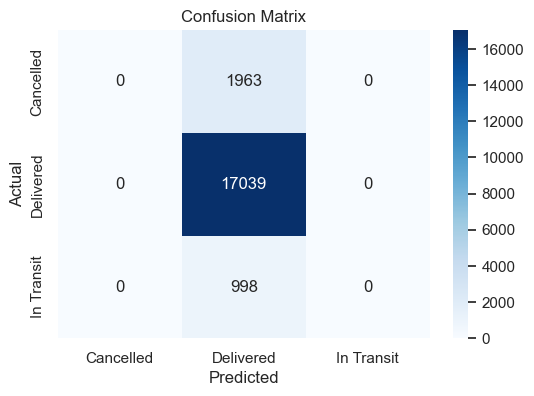

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Accuracy gives a general sense of performance, but the classification report is much more informative for our `price_range` prediction.  

- **Precision** answers: when the model predicts a specific price tier, how often is it correct?  
- **Recall** answers: out of all actual phones in a specific price tier, how many did the model successfully find?

The confusion matrix shows which price ranges the model confuses most often (for example, whether the model frequently confuses a Medium-priced phone for a High-priced one).

## 13. Feature importance (What mattered the most?)

Random Forest provides a built-in feature importance score, allowing us to see exactly which hardware specifications drive the `price_range` of a phone.  
Because we used one-hot encoding (for features like our engineered `battery_tier`), each categorical value becomes its own separate feature in the model.  
We will extract the final feature names from our pipeline and plot the top importances to discover if RAM, screen area, or something else is the strongest predictor of price!

In [22]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)


,feature,importance
16,ram,0.401909
24,ram_per_core,0.150999
3,battery_power,0.050863
15,px_width,0.049426
14,px_height,0.046414
12,n_cores,0.029682
11,mobile_wt,0.028333
9,int_memory,0.024475
23,screen_area,0.022871
19,talk_time,0.021422


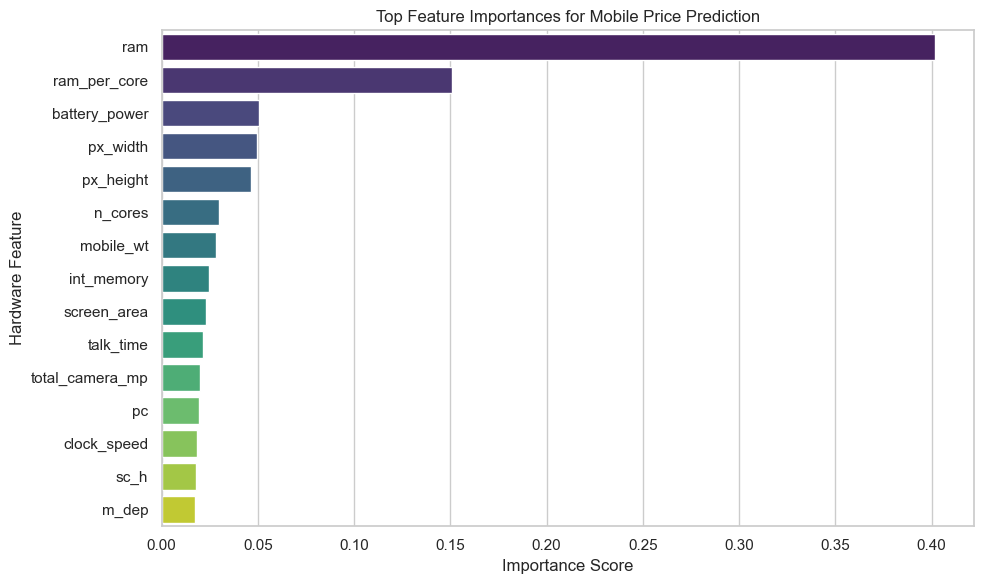

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=fi.head(15), hue="feature", palette="viridis", legend=False)
plt.title("Top Feature Importances for Mobile Price Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Hardware Feature")
plt.tight_layout()
plt.show()

### Interpretation of Feature Importances
Looking at the chart above, we can clearly see what drives the price of a mobile phone:
1. **RAM is King:** Both the raw `ram` and our engineered `ram_per_core` feature heavily dominate the model's decision-making. 
2. **Battery and Screen:** `battery_power` and our engineered `screen_area` also play massive roles in classifying the price tier.
3. **Engineered Features Worked:** Our domain-specific feature engineering (`ram_per_core` and `screen_area`) successfully captured highly important signals, proving that combining raw specifications into meaningful metrics improves the model's understanding of the data!

## 14. Optional: Feature selection using SelectFromModel

Sometimes, having too many features (even engineered ones) can introduce "noise" that confuses the model. 

In this section, we use `SelectFromModel` with a `median` threshold. This means the pipeline will:
1. Train an internal Random Forest to calculate feature importance.
2. Calculate the median importance score.
3. Automatically drop every feature that falls below that median.
4. Train the final model using only the "top-half" most important hardware specifications.

This helps us see if a leaner, more focused model can achieve similar or better accuracy than the full model.

In [ ]:
from sklearn.feature_selection import SelectFromModel

# Build a new pipeline that selects features based on RF importances
selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"  # keep features above the median importance
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))


Accuracy (with feature selection): 0.8925

Classification Report (with feature selection):
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       100
           1       0.84      0.82      0.83       100
           2       0.84      0.83      0.83       100
           3       0.96      0.95      0.95       100

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



By applying feature selection, we reduced the complexity of our model. 

If the accuracy remained stable or improved, it proves that many of the original hardware specifications were "noisy" or redundant, and that our engineered features (like RAM per core) were strong enough to carry the model's performance even with fewer total predictors.

## 15. Student tasks

## Lab 5 Tasks

### Task 1
Create one new engineered feature that you believe will help predict `price_range`. 
*Hint: Think about battery vs. thickness, or pixels per inch.*
Write one paragraph justifying your choice.

### Task 2
In Step 8, we binned the battery into 4 tiers. Try changing the `bins` or the `labels` (e.g., only 3 tiers: Low, Mid, High) and discuss whether the model accuracy or the feature importance of `battery_tier` changes.

### Task 3
Modify the `Random Forest` hyperparameters in Step 11. Change `n_estimators` to a much lower number (like 10) and then a much higher number (like 500) and compare:
- Total Accuracy
- Stability of the Feature Importance ranking

### Task 4
Look at the results from the Feature Selection section (Step 14). List which features were kept and which were dropped, and explain whether you think the model became better or worse after removing the bottom 50% of features.